## Notebook to compute test set evaluation metrics, confusion matrices, and train/val loss and accuracy curves

This notebook computes the final evaluation metrics (accuracy, F1-score, precision, recall) for all 3 experiments on the test set and generates confusion matrices for each. 

Additionally, train and validation loss and acucracy plots are generated. 

In [1]:
# Imports
import numpy as np 
import pandas as pd 
import os 

from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import precision_score, recall_score

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import matplotlib.pyplot as plt 
import seaborn as sns 

### Read in the results files 

In [2]:
# Config paths to folders for train/val and test results for all experiments 
TEST_RESULTS_DIR = "./res_since_20260506_0259/test_predictions" # dir for all test results
TRAIN_VAL_DIR  = "./res_since_20260506_0259/" # dir for train/val results 

# Save plots to folder 
PLOTS_DIR = "./plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

In [3]:
# Read in exp 1-3 test and true labels 
exp1_eval_pth = os.path.join(TEST_RESULTS_DIR,"exp1_frozen_test_predictions.csv")
df_exp1_eval = pd.read_csv(exp1_eval_pth)
print("exp1 Test Results:")
display(df_exp1_eval.head())

# Read in exp2 results
exp2_eval_pth = os.path.join(TEST_RESULTS_DIR,"exp2_finetune_test_predictions.csv")
df_exp2_eval = pd.read_csv(exp2_eval_pth)
print("exp2 Test Results:")
display(df_exp2_eval.head())

# Read in exp3 results
exp3_eval_pth = os.path.join(TEST_RESULTS_DIR,"exp3_hybrid_test_predictions.csv")
df_exp3_eval = pd.read_csv(exp3_eval_pth)
print("exp3 Test Results:")
display(df_exp3_eval.head())

exp1 Test Results:


,video_id,true_label,pred_label
0,14837,Stop Sign,Stop Sign
1,137745,Stop Sign,Swiping Left
2,17558,Stop Sign,Thumb Up
3,34122,Stop Sign,Stop Sign
4,101941,Stop Sign,Stop Sign


exp2 Test Results:


,video_id,true_label,pred_label
0,14837,Stop Sign,Stop Sign
1,137745,Stop Sign,Stop Sign
2,17558,Stop Sign,Stop Sign
3,34122,Stop Sign,Stop Sign
4,101941,Stop Sign,Stop Sign


exp3 Test Results:


,video_id,true_label,pred_label
0,14837,Stop Sign,Stop Sign
1,137745,Stop Sign,Stop Sign
2,17558,Stop Sign,Stop Sign
3,34122,Stop Sign,Stop Sign
4,101941,Stop Sign,Stop Sign


# Plot the Train/Val Loss and Accuracy vs. Epochs

In [4]:
# Read in the Train/Val data 
TRAIN_VAL_DIR = "./res_since_20260506_0259"

exp1 train/val Results:


,epoch,train_loss,val_loss,train_acc,val_acc
0,1,1.513137,1.428594,24.5000,23.0
1,2,1.508886,1.416901,24.0625,25.0
2,3,1.486496,1.403202,25.1875,27.0
3,4,1.446332,1.395112,26.8125,28.5
4,5,1.472903,1.391673,27.1875,31.0


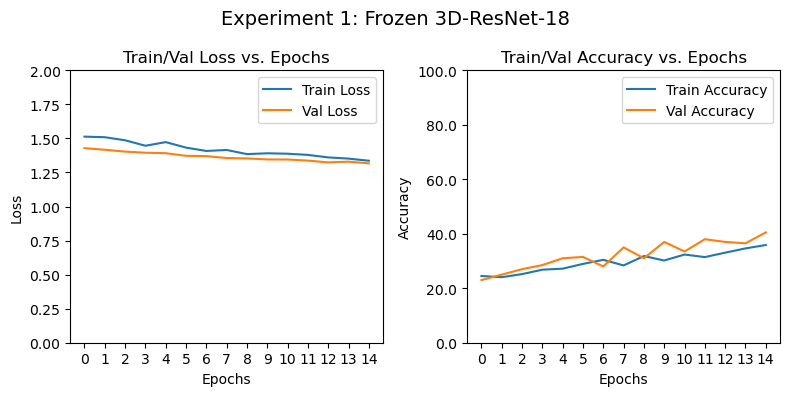

In [5]:
# Read in Exp1 Results 
import matplotlib.ticker as ticker
import os
exp1_train_val_pth = os.path.join(TRAIN_VAL_DIR,"exp1_metrics.csv")
df_exp1_train_val = pd.read_csv(exp1_train_val_pth)
print("exp1 train/val Results:")
display(df_exp1_train_val.head())

# Plot the Train/Val Loss vs. Epochs 
fig, axes = plt.subplots(1,2, figsize=(8,4))
plt.subplots_adjust(top=0.85)
axes[0].plot(df_exp1_train_val["train_loss"], label="Train Loss")
axes[0].plot(df_exp1_train_val["val_loss"], label="Val Loss")
axes[0].set_title("Train/Val Loss vs. Epochs")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].xaxis.set_major_locator(ticker.MultipleLocator(1))
axes[0].set_ylim(0.0, 2.0)

axes[1].plot(df_exp1_train_val["train_acc"], label="Train Accuracy")
axes[1].plot(df_exp1_train_val["val_acc"], label="Val Accuracy")
axes[1].set_title("Train/Val Accuracy vs. Epochs")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.0, 100.0)
axes[1].legend()
axes[1].xaxis.set_major_locator(ticker.MultipleLocator(1))
axes[1].yaxis.set_major_formatter('{x:.1f}')

fig.suptitle("Experiment 1: Frozen 3D-ResNet-18", size=14)
fig.tight_layout()
img_path = os.path.join(PLOTS_DIR, "exp1_train_val_plot.png")
plt.savefig(img_path, dpi=300, transparent=True)

exp2 train/val Results:


,epoch,train_loss,val_loss,train_acc,val_acc
0,1,0.901816,0.408545,61.5000,83.0
1,2,0.316931,0.347026,89.6875,84.0
2,3,0.192384,0.308943,93.1875,88.0
3,4,0.109536,0.286185,96.4375,88.0
4,5,0.107139,0.453544,96.5000,84.5


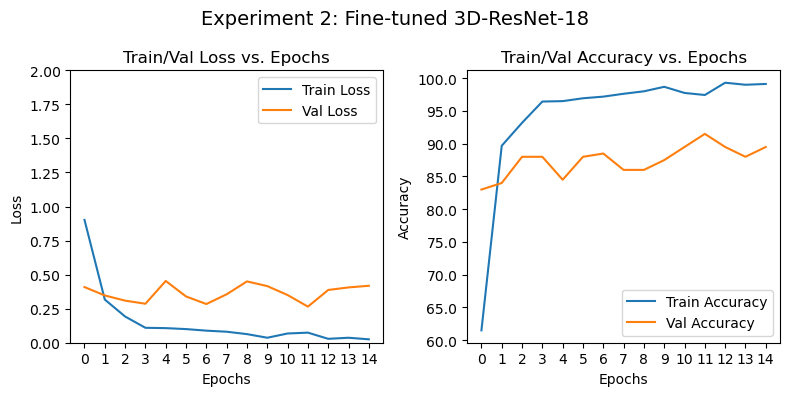

In [6]:
# Read in exp2 Results 
import matplotlib.ticker as ticker
exp2_train_val_pth = os.path.join(TRAIN_VAL_DIR,"exp2_metrics.csv")
df_exp2_train_val = pd.read_csv(exp2_train_val_pth)
print("exp2 train/val Results:")
display(df_exp2_train_val.head())

# Plot the Train/Val Loss vs. Epochs 
fig, axes = plt.subplots(1,2, figsize=(8,4))
plt.subplots_adjust(top=0.85)
axes[0].plot(df_exp2_train_val["train_loss"], label="Train Loss")
axes[0].plot(df_exp2_train_val["val_loss"], label="Val Loss")
axes[0].set_title("Train/Val Loss vs. Epochs")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].xaxis.set_major_locator(ticker.MultipleLocator(1))
axes[0].set_ylim(0.0, 2.0)

axes[1].plot(df_exp2_train_val["train_acc"], label="Train Accuracy")
axes[1].plot(df_exp2_train_val["val_acc"], label="Val Accuracy")
axes[1].set_title("Train/Val Accuracy vs. Epochs")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].xaxis.set_major_locator(ticker.MultipleLocator(1))
axes[1].yaxis.set_major_formatter('{x:.1f}')

fig.suptitle("Experiment 2: Fine-tuned 3D-ResNet-18", size=14)
fig.tight_layout()
img_path = os.path.join(PLOTS_DIR, "exp2_train_val_plot.png")
plt.savefig(img_path, dpi=300, transparent=True)

exp3 train/val Results:


,epoch,train_loss,val_loss,train_acc,val_acc
0,1,1.230164,0.874558,39.8125,65.5
1,2,0.714717,0.862643,73.8750,69.0
2,3,0.461355,0.772261,83.8750,77.0
3,4,0.299884,0.975503,90.7500,75.0
4,5,0.234933,1.092901,92.8125,76.0


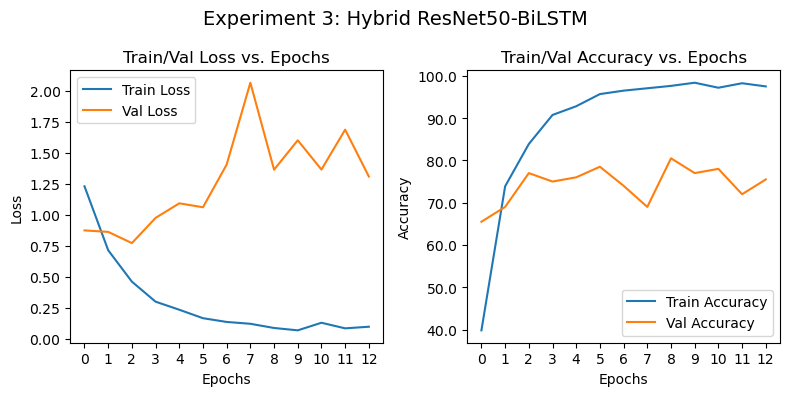

In [7]:
import matplotlib.ticker as ticker
exp3_train_val_pth = os.path.join(TRAIN_VAL_DIR,"exp3_metrics.csv")
df_exp3_train_val = pd.read_csv(exp3_train_val_pth)
print("exp3 train/val Results:")
display(df_exp3_train_val.head())

# Plot the Train/Val Loss vs. Epochs 
fig, axes = plt.subplots(1,2, figsize=(8,4))
plt.subplots_adjust(top=0.85)
axes[0].plot(df_exp3_train_val["train_loss"], label="Train Loss")
axes[0].plot(df_exp3_train_val["val_loss"], label="Val Loss")
axes[0].set_title("Train/Val Loss vs. Epochs")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].xaxis.set_major_locator(ticker.MultipleLocator(1))

axes[1].plot(df_exp3_train_val["train_acc"], label="Train Accuracy")
axes[1].plot(df_exp3_train_val["val_acc"], label="Val Accuracy")
axes[1].set_title("Train/Val Accuracy vs. Epochs")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].xaxis.set_major_locator(ticker.MultipleLocator(1))
axes[1].yaxis.set_major_formatter('{x:.1f}')

fig.suptitle("Experiment 3: Hybrid ResNet50-BiLSTM", size=14)
fig.tight_layout()
img_path = os.path.join(PLOTS_DIR, "exp3_train_val_plot.png")
plt.savefig(img_path, dpi=300, transparent=True)

## Overall Accuracy, Precision, Recall, F1-Score for Experiment 1 (Frozen ResNet3D-18)


exp1 results:
Accuracy: 0.3550
Precision: 0.3528
Recall: 0.3550
F1 Score: 0.3489
[[21 10  7 12]
 [13 25  3  9]
 [15 10 14 11]
 [13 15 11 11]]


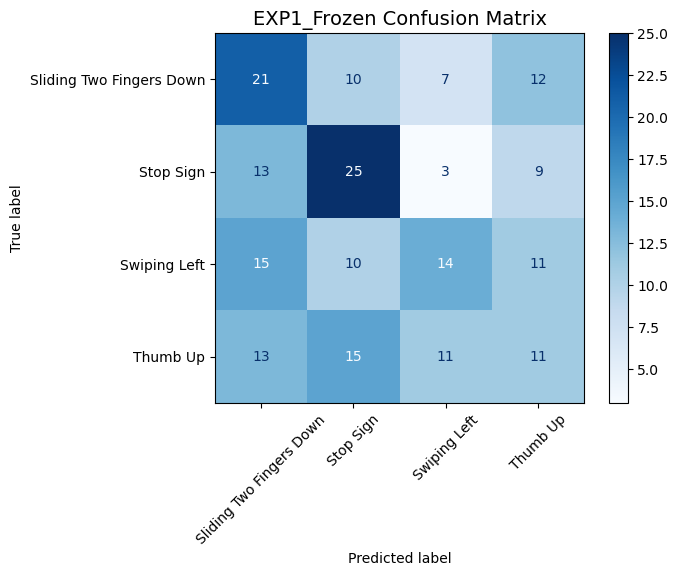

In [8]:
# Compute overall accuracy, F1-score for exp1 
y_pred = df_exp1_eval["pred_label"]
y_test = df_exp1_eval["true_label"]

# Compute overall accuracy 
accuracy = accuracy_score(y_test, y_pred)

# Compute weighted F1-score (will be the same as the macro-averaged because classes are all balanced)
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

# Compute precision, recall
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred,average='weighted' )

print("\nexp1 results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}") # TP / (TP + FP)
print(f"Recall: {recall:.4f}")       # TP / (TP + FN)
print(f"F1 Score: {weighted_f1:.4f}")




# Plot and save the confusion matrix

# Get the unique string labels 
labels = sorted(y_test.unique())

# Generate and plot matrix
cm_exp1 = confusion_matrix(y_test, y_pred, labels=labels)
print(cm_exp1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_exp1,
                               display_labels=labels)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("EXP1_Frozen Confusion Matrix", fontsize=14)
img_path = os.path.join(PLOTS_DIR, "exp1_conf_matrix.png")
plt.savefig(img_path, dpi=300, transparent=True, bbox_inches='tight')
plt.show()

## Overall Accuracy, Precision, Recall, F1-Score for Experiment 2 (Fine-tuned ResNet3D-18)


exp2 results:
Accuracy: 0.8800
Precision: 0.8798
Recall: 0.8800
F1 Score: 0.8789
[[43  2  3  2]
 [ 2 44  2  2]
 [ 0  0 49  1]
 [ 5  5  0 40]]


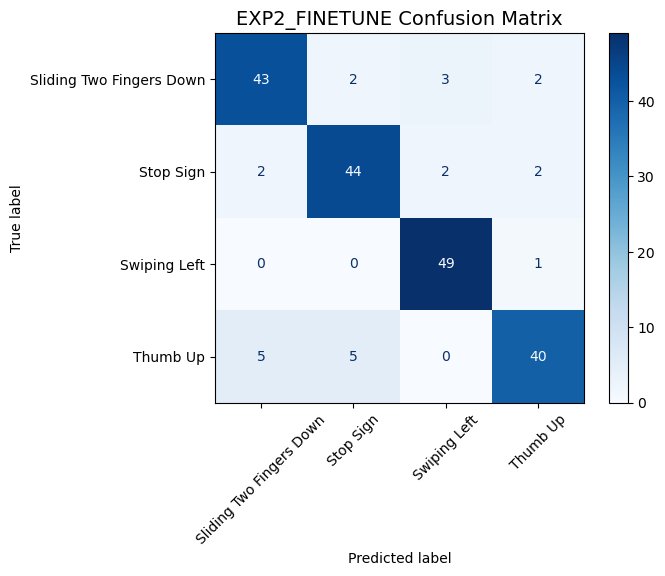

In [9]:
# Compute overall accuracy, F1-score for exp2 
y_pred = df_exp2_eval["pred_label"]
y_test = df_exp2_eval["true_label"]

# Compute overall accuracy 
accuracy = accuracy_score(y_test, y_pred)

# Compute weighted F1-score (will be the same as the macro-averaged because classes are all balanced)
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

# Compute precision, recall
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted' )

print("\nexp2 results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}") # TP / (TP + FP)
print(f"Recall: {recall:.4f}")       # TP / (TP + FN)
print(f"F1 Score: {weighted_f1:.4f}")


# Get the unique string labels 
labels = sorted(y_test.unique())

# Generate and plot matrix
cm_exp2 = confusion_matrix(y_test, y_pred, labels=labels)
print(cm_exp2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_exp2,
                               display_labels=labels)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("EXP2_FINETUNE Confusion Matrix", fontsize=14)
img_path = os.path.join(PLOTS_DIR, "exp2_conf_matrix.png")
plt.savefig(img_path, dpi=300, transparent=True, bbox_inches='tight')
plt.show()

## Overall Accuracy, Precision, Recall, F1-Score for Experiment 3 (HYBRID RESNET-50-LSTM Model)


exp3 results:
Accuracy: 0.7800
Precision: 0.7889
Recall: 0.7800
F1 Score: 0.7713
[[26 10  9  5]
 [ 0 46  1  3]
 [ 3  1 45  1]
 [ 2  3  6 39]]


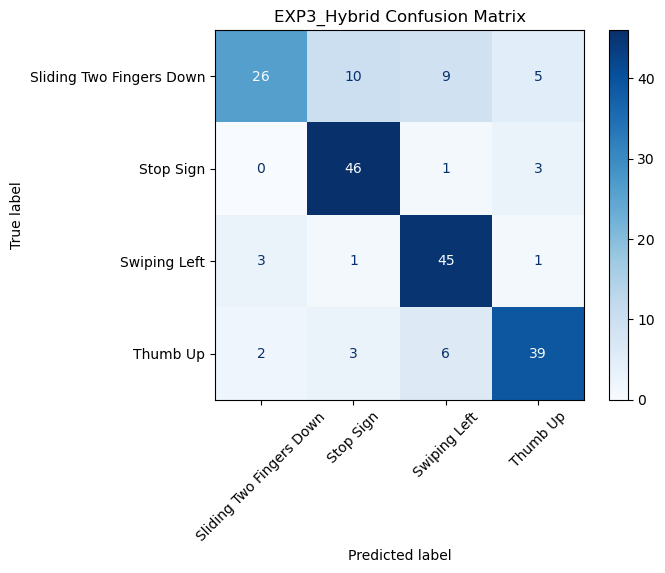

In [ ]:
# Compute overall accuracy, F1-score for exp3 
y_pred = df_exp3_eval["pred_label"]
y_test = df_exp3_eval["true_label"]

# Compute overall accuracy 
accuracy = accuracy_score(y_test, y_pred)

# Compute weighted F1-score (will be the same as the macro-averaged because classes are all balanced)
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

# Compute precision, recall
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted' )

print("\nexp3 results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}") # TP / (TP + FP)
print(f"Recall: {recall:.4f}")       # TP / (TP + FN)
print(f"F1 Score: {weighted_f1:.4f}")

# Generate and plot matrix
cm_exp3 = confusion_matrix(y_test, y_pred, labels=labels)
print(cm_exp3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_exp3,
                               display_labels=labels)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("EXP3_Hybrid Confusion Matrix")
img_path = os.path.join(PLOTS_DIR, "exp3_conf_matrix.png")
plt.savefig(img_path, dpi=300, transparent=True, bbox_inches='tight')
plt.show()